<a href="https://colab.research.google.com/github/Bhaskar20A91A0395/repo1/blob/secondmaster/Myntra_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
products=pd.read_excel("/content/Myntra dataset (3) (1).xlsx",sheet_name="dim_products")

In [3]:
customers=pd.read_excel("/content/Myntra dataset (3) (1).xlsx",sheet_name="dim_customers")

In [4]:
orders=pd.read_excel("/content/Myntra dataset (3) (1).xlsx",sheet_name="fact_orders")

In [5]:
products.duplicated().sum()

0

In [6]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3071 entries, 0 to 3070
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product ID    3071 non-null   object
 1   Category      3071 non-null   object
 2   Sub-category  3071 non-null   object
 3   Product Name  3071 non-null   object
 4   Brand Name    3071 non-null   object
 5   Size          3071 non-null   object
 6   Color         3071 non-null   object
 7   Ratings       3071 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 192.1+ KB


In [7]:
orders.duplicated().sum()

0

In [8]:
orders['Month']=orders['Date'].dt.strftime("%B")

In [9]:
orders

,Order ID,Customer ID,Product ID,Date,Original Price,Discount%,Month
0,OD0001,C001,P0001,2023-02-16,349,0.30,February
1,OD0002,C002,P0001,2022-09-22,350,0.30,September
2,OD0003,C003,P0001,2021-06-14,351,0.30,June
3,OD0004,C004,P0001,2021-09-10,352,0.25,September
4,OD0005,C005,P0001,2021-10-18,353,0.25,October
...,...,...,...,...,...,...,...
3495,OD3496,C081,P3071,2021-05-24,785,0.50,May
3496,OD3497,C082,P3071,2022-09-11,751,0.50,September
3497,OD3498,C083,P3071,2022-12-28,1576,0.50,December
3498,OD3499,C084,P3071,2022-02-05,692,0.50,February


In [11]:
gb=orders.groupby('Month').agg({'Order ID':'count'})

In [12]:
gb

,Order ID
Month,
April,266
August,258
December,250
February,368
January,395
July,269
June,259
March,380
May,242


In [13]:
orders['total_price']=orders['Original Price']-(orders['Original Price']*orders['Discount%'])

In [14]:
orders

,Order ID,Customer ID,Product ID,Date,Original Price,Discount%,Month,total_price
0,OD0001,C001,P0001,2023-02-16,349,0.30,February,244.30
1,OD0002,C002,P0001,2022-09-22,350,0.30,September,245.00
2,OD0003,C003,P0001,2021-06-14,351,0.30,June,245.70
3,OD0004,C004,P0001,2021-09-10,352,0.25,September,264.00
4,OD0005,C005,P0001,2021-10-18,353,0.25,October,264.75
...,...,...,...,...,...,...,...,...
3495,OD3496,C081,P3071,2021-05-24,785,0.50,May,392.50
3496,OD3497,C082,P3071,2022-09-11,751,0.50,September,375.50
3497,OD3498,C083,P3071,2022-12-28,1576,0.50,December,788.00
3498,OD3499,C084,P3071,2022-02-05,692,0.50,February,346.00


Text(0, 0.5, 'no of orders')

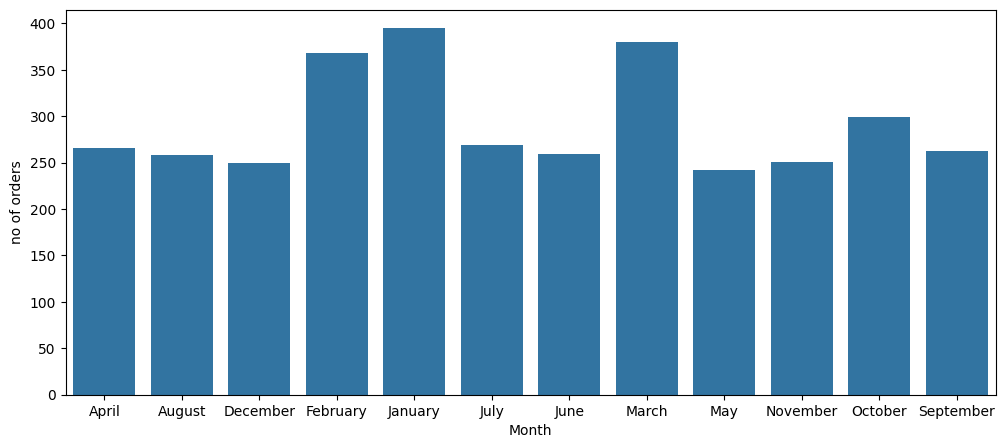

In [18]:
plt.figure(figsize=(12,5))
map=sns.barplot(x=gb.index,y=gb['Order ID'])
plt.ylabel('no of orders')

In [19]:
products

,Product ID,Category,Sub-category,Product Name,Brand Name,Size,Color,Ratings
0,P0001,Women,Topwear,T-Shirts,Roadster,40,Black,4
1,P0002,Women,Topwear,T-Shirts,Roadster,40,Blue,5
2,P0003,Women,Topwear,T-Shirts,Roadster,42,White,3
3,P0004,Women,Topwear,T-Shirts,Roadster,44,Green,2
4,P0005,Women,Topwear,T-Shirts,Puma,38,Olive,5
...,...,...,...,...,...,...,...,...
3066,P3067,Kids,Footwear,Sandals,Campus,9-12M,Olive,5
3067,P3068,Kids,Footwear,Sandals,Campus,9-12M,Teal,3
3068,P3069,Kids,Footwear,Sandals,Campus,3-6M,Sea Green,5
3069,P3070,Kids,Footwear,Sandals,Campus,3-6M,Turquoise Blue,5


In [22]:
gb2=orders.groupby('Month').agg({'total_price':'sum'})

In [23]:
gb2

,total_price
Month,
April,135256.24
August,147410.04
December,130579.69
February,209187.97
January,205141.90
July,146894.08
June,132804.51
March,212976.54
May,132229.55


In [40]:
orders['total_price'].sum()

1877170.32

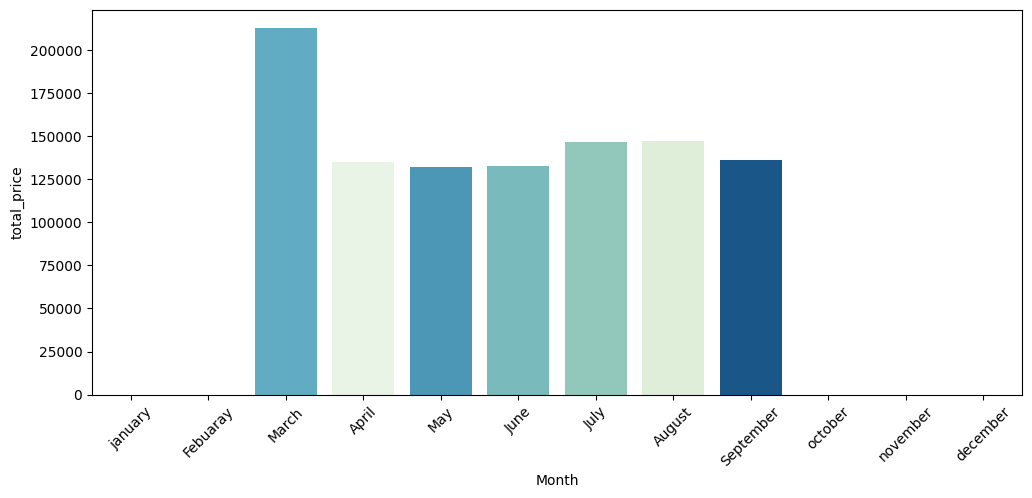

In [34]:
plt.figure(figsize=(12,5))
map1=sns.barplot(x=gb2.index,y=gb2['total_price'],order=['january','Febuaray','March','April','May','June','July','August','September',
                                                         'october','november','december'],hue=gb2.index,palette='GnBu')
plt.xticks(rotation=45)
plt.show()

In [20]:
joined=pd.merge(left=orders,right=products,how='inner',on='Product ID')

In [21]:
joined

,Order ID,Customer ID,Product ID,Date,Original Price,Discount%,Month,total_price,Category,Sub-category,Product Name,Brand Name,Size,Color,Ratings
0,OD0001,C001,P0001,2023-02-16,349,0.30,February,244.30,Women,Topwear,T-Shirts,Roadster,40,Black,4
1,OD0002,C002,P0001,2022-09-22,350,0.30,September,245.00,Women,Topwear,T-Shirts,Roadster,40,Black,4
2,OD0003,C003,P0001,2021-06-14,351,0.30,June,245.70,Women,Topwear,T-Shirts,Roadster,40,Black,4
3,OD0004,C004,P0001,2021-09-10,352,0.25,September,264.00,Women,Topwear,T-Shirts,Roadster,40,Black,4
4,OD0005,C005,P0001,2021-10-18,353,0.25,October,264.75,Women,Topwear,T-Shirts,Roadster,40,Black,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495,OD3496,C081,P3071,2021-05-24,785,0.50,May,392.50,Kids,Footwear,Sandals,Campus,3-6M,Charcoal,4
3496,OD3497,C082,P3071,2022-09-11,751,0.50,September,375.50,Kids,Footwear,Sandals,Campus,3-6M,Charcoal,4
3497,OD3498,C083,P3071,2022-12-28,1576,0.50,December,788.00,Kids,Footwear,Sandals,Campus,3-6M,Charcoal,4
3498,OD3499,C084,P3071,2022-02-05,692,0.50,February,346.00,Kids,Footwear,Sandals,Campus,3-6M,Charcoal,4


In [35]:
gb3=joined.groupby('Category').agg({'total_price':'sum'})

([<matplotlib.patches.Wedge at 0x78d43c8b0b10>,
 [Text(0.9534051185914273, 0.5486516926463151, 'Beauty'),
  Text(-0.21439611724566388, 1.078904214891194, 'Kids'),
  Text(-1.0408477995978138, -0.35585932343046695, 'Men'),
  Text(0.6704742976138526, -0.8720459943370024, 'Women')],
 [Text(0.520039155595324, 0.29926455962526277, '16.62'),
  Text(-0.116943336679453, 0.5884932081224694, '23.00'),
  Text(-0.5677351634169893, -0.1941050855075274, '31.24'),
  Text(0.3657132532439195, -0.4756614514565467, '29.14')])

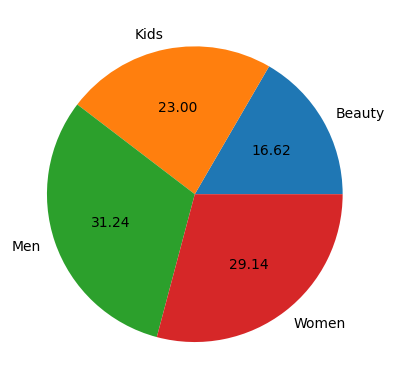

In [39]:
plt.pie(gb3['total_price'],labels=gb3.index,autopct="%1.2f")

In [41]:
gb4=joined.groupby('Product Name').agg({'total_price':'sum'})

([<matplotlib.patches.Wedge at 0x78d43c9a0b10>,
 [Text(1.09979750261838, 0.02110576306070176, 'Body Lotion'),
  Text(1.0973674113387657, 0.07605763953513464, 'Bodysuits'),
  Text(1.0910437660672172, 0.1400839053062964, 'Boots'),
  Text(1.0721972425474564, 0.24575002151298186, 'Casual Shoes'),
  Text(1.0426636321165574, 0.35050328138479453, 'Cleanser'),
  Text(1.0172310323272524, 0.41861799635279934, 'Compact'),
  Text(0.9745227028996977, 0.5102014323118543, 'Conditioner'),
  Text(0.9249227635602688, 0.5954140420312872, 'Dupattas'),
  Text(0.8493607714324931, 0.6989894705584629, 'Ethnic Wear'),
  Text(0.7690328003271311, 0.7865040063604325, 'Eyeliner'),
  Text(0.7182066899594539, 0.8331741417599835, 'Facewash'),
  Text(0.5918846253704612, 0.9271853052384238, 'Flats'),
  Text(0.454287968823574, 1.001809583395044, 'Formal Shoes'),
  Text(0.39322923983974645, 1.027312398900673, 'Hair Gel'),
  Text(0.31324894344302656, 1.0544548825966087, 'Heels'),
  Text(0.08210097073117648, 1.096931825869

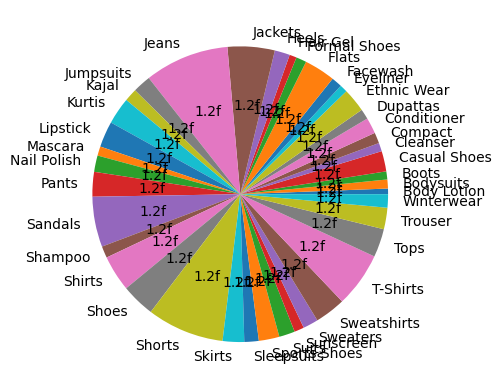

In [46]:
plt.pie(gb4['total_price'],labels=gb4.index,autopct="1.2f")